# Experiment 8 — Introduction to Computer Vision

Computer vision is a multidisciplinary field that enables machines to interpret and understand visual data such as images and videos. In this experiment, we explore different fields of computer vision, starting with basics of image manipulation and going to more advanced problems such as object recognition and detection.

**Main libraries used:** OpenCV, Scikit-learn, PyTorch

## Setup — Install Dependencies

In [6]:
!pip install opencv-python torch torchvision matplotlib numpy

---
## Part 1.1 — Image Processing and Manipulation with OpenCV

### Download the BZU Campus Image

In [7]:
!wget https://www.birzeit.edu/sites/default/files/buildings.jpg

--2026-05-22 13:42:59--  https://www.birzeit.edu/sites/default/files/buildings.jpg
Resolving www.birzeit.edu (www.birzeit.edu)... 104.20.23.190, 172.66.148.78, 2606:4700:10::6814:17be, ...
Connecting to www.birzeit.edu (www.birzeit.edu)|104.20.23.190|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-05-22 13:43:00 ERROR 403: Forbidden.



---
### Code Snippet 1.1 — Loading and Displaying an Image

In [8]:
import cv2 as cv

img_path = r"معهد العلم المفدى.png"
image = cv.imread(img_path)

if image is None:
    print("❌ Image not found — check the path")
else:
    print(f"✅ Image loaded — shape: {image.shape}")

✅ Image loaded — shape: (630, 1200, 3)


#### ✅ Task 1 — What is the shape of the loaded image? What does each dimension represent?

In [9]:
print('Image shape:', image.shape)
# Shape is (Height, Width, Channels)
# Height: number of rows (pixels vertically)
# Width:  number of columns (pixels horizontally)
# Channels: 3 (Blue, Green, Red in OpenCV's BGR order)

Image shape: (630, 1200, 3)


**Answer:** The shape is `(H, W, 3)`. The three dimensions are:
- **H** — height (number of pixel rows)
- **W** — width (number of pixel columns)
- **3** — color channels in BGR order (Blue, Green, Red)

#### ✅ Task 2 — Pass the image directly to `plt.imshow()` without `cv.cvtColor()`. What difference do you notice and why?

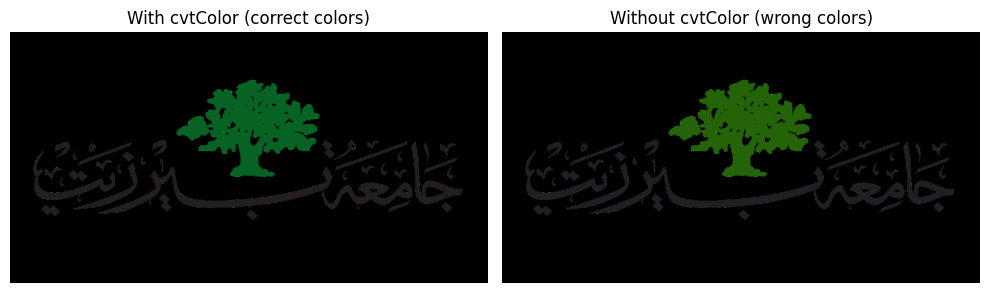

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('With cvtColor (correct colors)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image)  # No color conversion
plt.title('Without cvtColor (wrong colors)')
plt.axis('off')

plt.tight_layout()
plt.show()

**Answer:** Without `cvtColor`, the image looks color-distorted (blue tones appear red and vice versa). OpenCV loads images in **BGR** channel order, whereas Matplotlib's `imshow` expects **RGB**. The blue and red channels are swapped, causing incorrect color rendering.

---
### Code Snippet 1.2 — Grayscale Conversion

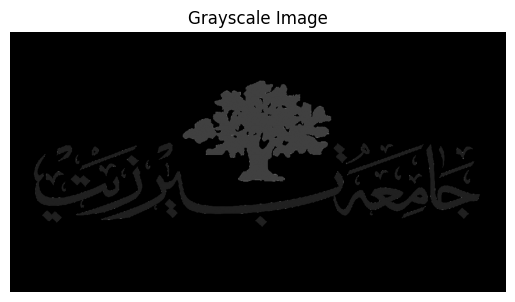

In [11]:
# Convert the image to grayscale
gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# Display the grayscale image
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

#### ✅ Task 3 — What is the shape of the gray image? What does each dimension represent?

In [12]:
print('Grayscale image shape:', gray_image.shape)

Grayscale image shape: (630, 1200)


**Answer:** The shape is `(H, W)` — only two dimensions. The channel dimension is gone because grayscale has a single intensity value per pixel (0 = black, 255 = white), so no separate color channels are needed.

---
### Code Snippet 1.3 — Image Transformation

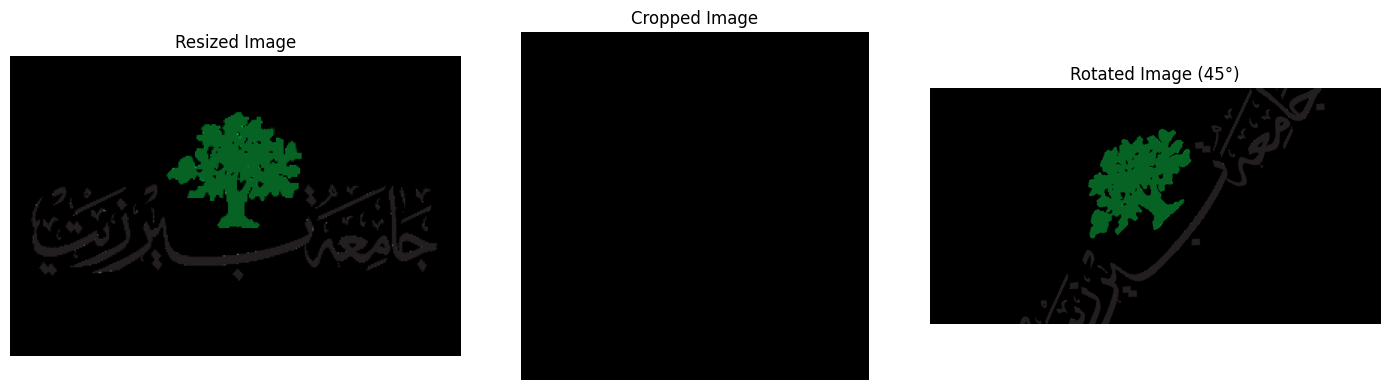

In [13]:
import numpy as np

image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Resize and crop
resized_image = cv.resize(image_rgb, (300, 200))
cropped_image = image_rgb[50:250, 50:250]

# Rotate 45° clockwise around the center
rows, cols = image_rgb.shape[:2]
M = cv.getRotationMatrix2D((cols / 2, rows / 2), 45, 1)
rotated_image = cv.warpAffine(image_rgb, M, (cols, rows))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(resized_image);  axes[0].set_title('Resized Image');  axes[0].axis('off')
axes[1].imshow(cropped_image);  axes[1].set_title('Cropped Image');  axes[1].axis('off')
axes[2].imshow(rotated_image);  axes[2].set_title('Rotated Image (45°)'); axes[2].axis('off')
plt.tight_layout()
plt.show()

**Explanation of transformations:**
- **Resize:** `cv.resize(image, (300, 200))` scales the image to exactly 300×200 pixels (width × height).
- **Crop:** NumPy slicing `image[50:250, 50:250]` extracts a 200×200 pixel region starting at row 50, column 50.
- **Rotate:** `cv.getRotationMatrix2D(center, angle, scale)` builds a 2×3 affine matrix for a 45° rotation around the image center. `cv.warpAffine` applies it.

#### ✅ Task 4 — Rotate the original image by 10° counter-clockwise around the upper-left corner

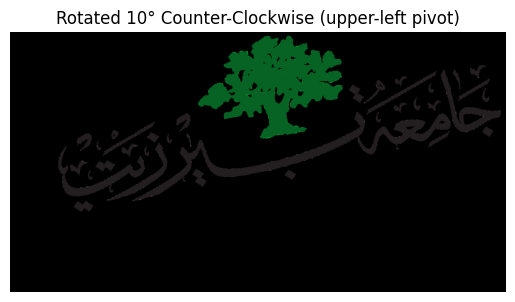

In [14]:
rows, cols = image_rgb.shape[:2]

# Upper-left corner = (0, 0)
# Positive angle = counter-clockwise in OpenCV's convention
M_task4 = cv.getRotationMatrix2D((0, 0), 10, 1)
rotated_ccw = cv.warpAffine(image_rgb, M_task4, (cols, rows))

plt.imshow(rotated_ccw)
plt.title('Rotated 10° Counter-Clockwise (upper-left pivot)')
plt.axis('off')
plt.show()

---
### Code Snippet 1.4 — Gaussian Blurring

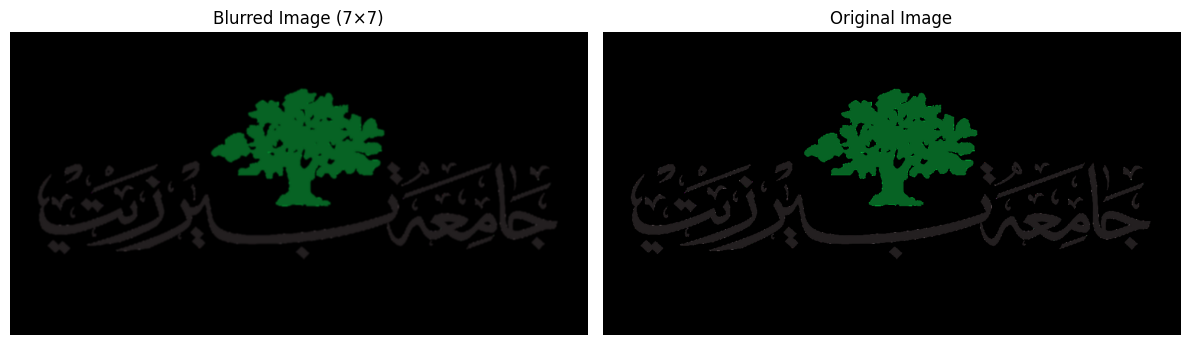

In [15]:
blurred_image = cv.GaussianBlur(image_rgb, (7, 7), 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(blurred_image); axes[0].set_title('Blurred Image (7×7)'); axes[0].axis('off')
axes[1].imshow(image_rgb);     axes[1].set_title('Original Image');       axes[1].axis('off')
plt.tight_layout()
plt.show()

#### ✅ Task 5 — What does `(7, 7)` represent? What happens when you increase it?

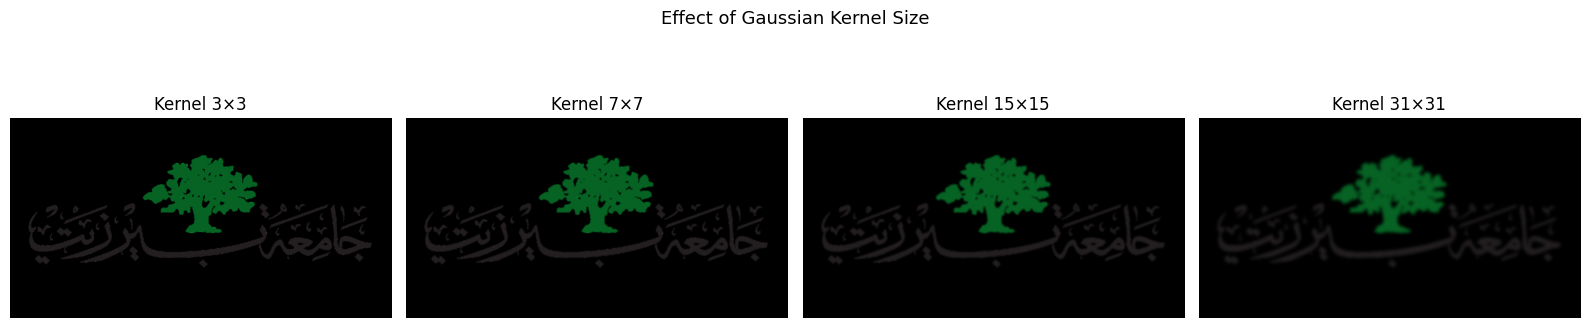

In [16]:
# Demonstrate different kernel sizes
kernel_sizes = [3, 7, 15, 31]
fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(16, 4))

for ax, k in zip(axes, kernel_sizes):
    blurred = cv.GaussianBlur(image_rgb, (k, k), 0)
    ax.imshow(blurred)
    ax.set_title(f'Kernel {k}×{k}')
    ax.axis('off')

plt.suptitle('Effect of Gaussian Kernel Size', fontsize=13)
plt.tight_layout()
plt.show()

**Answer:** `(7, 7)` is the **kernel size** — the width and height (in pixels) of the Gaussian filter window (must be odd). Increasing the kernel size makes the blur stronger and removes more fine detail/noise, at the cost of reduced sharpness. A very large kernel (e.g., 31×31) produces a heavily smoothed, almost unrecognizable image.

---
### Code Snippet 1.5 — Edge Detection

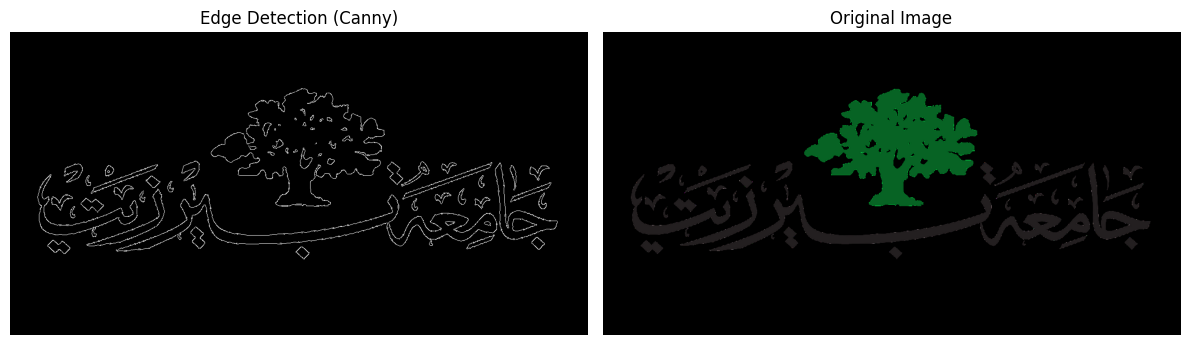

In [17]:
edges = cv.Canny(gray_image, 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(edges, cmap='gray'); axes[0].set_title('Edge Detection (Canny)'); axes[0].axis('off')
axes[1].imshow(image_rgb);         axes[1].set_title('Original Image');          axes[1].axis('off')
plt.tight_layout()
plt.show()

#### ✅ Task 6 — Explain the parameters of `cv.Canny()` and their effect

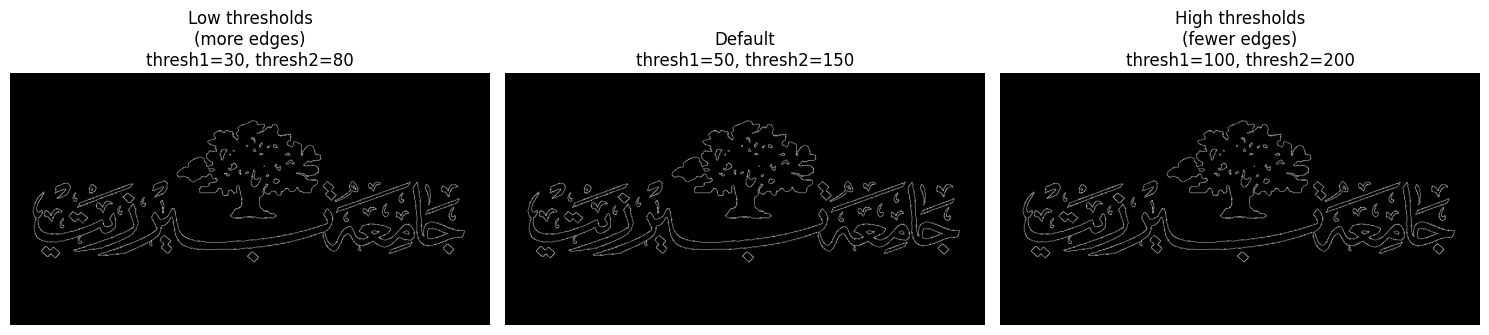

In [18]:
# Visualize different threshold combinations
configs = [(30, 80, 'Low thresholds\n(more edges)'),
           (50, 150, 'Default'),
           (100, 200, 'High thresholds\n(fewer edges)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (low, high, label) in zip(axes, configs):
    e = cv.Canny(gray_image, low, high)
    ax.imshow(e, cmap='gray')
    ax.set_title(f'{label}\nthresh1={low}, thresh2={high}')
    ax.axis('off')
plt.tight_layout()
plt.show()

**Answer:**
- `gray_image` — the source single-channel image.
- `threshold1` (50) — **lower threshold**: gradients below this are discarded (not edges).
- `threshold2` (150) — **upper threshold**: gradients above this are definitely edges.
- Gradients between the two thresholds are kept only if they are connected to a definite edge (hysteresis). Lowering both thresholds detects more (noisier) edges; raising them keeps only the strongest edges.

---
## Part 1.2 — Image Classification / Object Recognition

### 1.2.1 Image Classification with MLP

### Code Snippet 1.6 — Loading and Normalizing CIFAR-10

In [19]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                           shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print('CIFAR-10 loaded successfully.')
print(f'Training samples: {len(trainset)} | Test samples: {len(testset)}')

100%|██████████| 170M/170M [00:05<00:00, 29.4MB/s]


CIFAR-10 loaded successfully.
Training samples: 50000 | Test samples: 10000


### Code Snippet 1.7 — Displaying Sample Training Images

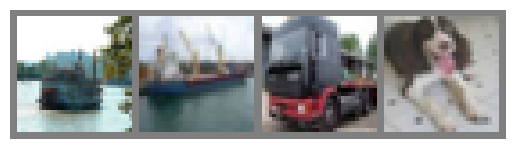

ship     ship     truck    dog     


In [20]:
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize from [-1,1] back to [0,1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))

# Print labels
print(' '.join(f'{classes[labels[j]]:8s}' for j in range(batch_size)))

#### ✅ Task 7 — Explain `transforms.ToTensor()` and `transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))`

**Answer:**
- **`ToTensor()`** converts a PIL Image (H×W×C, range [0, 255]) to a PyTorch tensor of shape (C×H×W) and rescales pixel values to the range **[0.0, 1.0]**.
- **`Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))`** applies per-channel normalization: `output = (input - mean) / std`. With mean=0.5 and std=0.5, values in [0,1] are mapped to **[-1, 1]**. This centers the data around zero, which helps gradient-based training converge faster.

#### ✅ Task 8 — What is the purpose of `np.transpose(npimg, (1, 2, 0))`?

**Answer:** PyTorch tensors store images as **(C, H, W)** (channels first). Matplotlib's `imshow` expects **(H, W, C)** (channels last). `np.transpose(npimg, (1, 2, 0))` reorders the axes from `(C, H, W)` → `(H, W, C)` so Matplotlib can display the image correctly.

### Define the MLP Network

In [21]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(3072, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

net = Net().to(device)
print(net)

Using device: cuda:0
Net(
  (fc1): Linear(in_features=3072, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


#### ✅ Task 9 — What does 3072 in `nn.Linear(3072, 64)` represent?

**Answer:** CIFAR-10 images are **3 × 32 × 32** (3 color channels, 32×32 pixels). When flattened into a 1D vector: `3 × 32 × 32 = 3072`. This is the total number of input features the first fully connected layer receives.

### Define Loss Function and Optimizer

In [22]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### Train the MLP Network

In [23]:
net.train()

for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = net(torch.flatten(inputs, 1))
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training MLP')

[Epoch 1, Batch  2000] loss: 1.934
[Epoch 1, Batch  4000] loss: 1.741
[Epoch 1, Batch  6000] loss: 1.674
[Epoch 1, Batch  8000] loss: 1.640
[Epoch 1, Batch 10000] loss: 1.601
[Epoch 1, Batch 12000] loss: 1.593
[Epoch 2, Batch  2000] loss: 1.521
[Epoch 2, Batch  4000] loss: 1.498
[Epoch 2, Batch  6000] loss: 1.507
[Epoch 2, Batch  8000] loss: 1.500
[Epoch 2, Batch 10000] loss: 1.502
[Epoch 2, Batch 12000] loss: 1.465
Finished Training MLP


### Evaluate the MLP Network

In [24]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = net(torch.flatten(images, 1))
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'MLP Accuracy on 10,000 test images: {100 * correct / total:.1f}%')

MLP Accuracy on 10,000 test images: 46.1%


---
## Part 1.2.2 — Image Classification with CNNs

### Define the CNN Network

In [25]:
class NetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)       # in_channels=3, out_channels=6, kernel=5
        self.pool  = nn.MaxPool2d(2, 2)        # kernel=2, stride=2
        self.conv2 = nn.Conv2d(6, 16, 5)      # in_channels=6, out_channels=16, kernel=5
        self.fc1   = nn.Linear(16 * 5 * 5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> 6 x 14 x 14
        x = self.pool(F.relu(self.conv2(x)))  # -> 16 x 5 x 5
        x = torch.flatten(x, 1)               # -> 400
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

cnn_net = NetCNN().to(device)
print(cnn_net)

NetCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


#### ✅ Task 10 — Study the CNN and answer the following questions

**How many layers does the network have?**  
5 learnable layers: `conv1`, `conv2`, `fc1`, `fc2`, `fc3`. (`pool` is non-learnable.)

**Parameters of `nn.Conv2d(in_ch, out_ch, kernel_size)`:**  
- `in_channels` — number of input feature maps (e.g., 3 for RGB)
- `out_channels` — number of filters / output feature maps
- `kernel_size` — size of the square convolving kernel (5 means 5×5)

**Parameters of `nn.MaxPool2d(kernel_size, stride)`:**  
- `kernel_size=2` — size of the pooling window (2×2)
- `stride=2` — step size the window moves; here it halves the spatial dimensions each time.

**Why `16 * 5 * 5` in `fc1`?**  
Input image: 32×32. After `conv1` (5×5 kernel, no padding): 28×28. After `pool` (÷2): 14×14. After `conv2` (5×5): 10×10. After `pool` (÷2): **5×5**. With 16 output channels from `conv2`, the flattened vector size = `16 × 5 × 5 = 400`.

### Train the CNN Network

In [26]:
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.SGD(cnn_net.parameters(), lr=0.001, momentum=0.9)

cnn_net.train()
for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_cnn.zero_grad()
        # Note: NO torch.flatten here — CNN expects (B, C, H, W)
        outputs = cnn_net(inputs)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[Epoch {epoch+1}, Batch {i+1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training CNN')

[Epoch 1, Batch  2000] loss: 2.214
[Epoch 1, Batch  4000] loss: 1.860
[Epoch 1, Batch  6000] loss: 1.681
[Epoch 1, Batch  8000] loss: 1.575
[Epoch 1, Batch 10000] loss: 1.544
[Epoch 1, Batch 12000] loss: 1.481
[Epoch 2, Batch  2000] loss: 1.424
[Epoch 2, Batch  4000] loss: 1.374
[Epoch 2, Batch  6000] loss: 1.359
[Epoch 2, Batch  8000] loss: 1.350
[Epoch 2, Batch 10000] loss: 1.313
[Epoch 2, Batch 12000] loss: 1.294
Finished Training CNN


### Evaluate the CNN Network

In [27]:
correct = 0
total = 0

cnn_net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'CNN Accuracy on 10,000 test images: {100 * correct / total:.1f}%')

CNN Accuracy on 10,000 test images: 55.0%


---
## Part 1.2.3 — Transfer Learning with AlexNet

> ⚠️ **GPU strongly recommended for this section.** Training on CPU will be very slow.

### Updated Data Transforms for AlexNet (expects 224×224 input)

In [28]:
from torchvision import models

transform_alexnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

trainset_alex = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform_alexnet)
trainloader_alex = torch.utils.data.DataLoader(trainset_alex, batch_size=32,
                                                shuffle=True, num_workers=2)

testset_alex = torchvision.datasets.CIFAR10(root='./data', train=False,
                                             download=True, transform=transform_alexnet)
testloader_alex = torch.utils.data.DataLoader(testset_alex, batch_size=32,
                                               shuffle=False, num_workers=2)

print('AlexNet data loaders ready.')

AlexNet data loaders ready.


### Fine-tune Pre-trained AlexNet

In [29]:
# Load AlexNet pre-trained on ImageNet
alex_pretrained = models.alexnet(weights='IMAGENET1K_V1')

# Replace the final classification layer: 4096 -> 10 (CIFAR-10 classes)
alex_pretrained.classifier[6] = nn.Linear(4096, 10)
alex_pretrained = alex_pretrained.to(device)

print('Pre-trained AlexNet loaded.')
print(alex_pretrained)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 180MB/s]


Pre-trained AlexNet loaded.
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out

In [30]:
def train_model(model, loader, epochs=2, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(loader, 0):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if i % 200 == 199:
                print(f'  [Epoch {epoch+1}, Batch {i+1:4d}] loss: {running_loss/200:.3f}')
                running_loss = 0.0
    print('Training complete.')


def evaluate_model(model, loader, label='Model'):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f'{label} Accuracy: {100 * correct / total:.1f}%')


print('Training pre-trained AlexNet (fine-tuning)...')
train_model(alex_pretrained, trainloader_alex, epochs=2)
evaluate_model(alex_pretrained, testloader_alex, label='Fine-tuned AlexNet')

Training pre-trained AlexNet (fine-tuning)...
  [Epoch 1, Batch  200] loss: 1.027
  [Epoch 1, Batch  400] loss: 0.691
  [Epoch 1, Batch  600] loss: 0.645
  [Epoch 1, Batch  800] loss: 0.588
  [Epoch 1, Batch 1000] loss: 0.547
  [Epoch 1, Batch 1200] loss: 0.524
  [Epoch 1, Batch 1400] loss: 0.523
  [Epoch 2, Batch  200] loss: 0.396
  [Epoch 2, Batch  400] loss: 0.427
  [Epoch 2, Batch  600] loss: 0.413
  [Epoch 2, Batch  800] loss: 0.401
  [Epoch 2, Batch 1000] loss: 0.396
  [Epoch 2, Batch 1200] loss: 0.388
  [Epoch 2, Batch 1400] loss: 0.391
Training complete.
Fine-tuned AlexNet Accuracy: 87.8%


### AlexNet — Learning from Scratch (No Pre-trained Weights)

In [31]:
# AlexNet with random (scratch) initialization
alex_scratch = models.alexnet()  # no pretrained weights
alex_scratch.classifier[6] = nn.Linear(4096, 10)
alex_scratch = alex_scratch.to(device)

print('Training AlexNet from scratch...')
train_model(alex_scratch, trainloader_alex, epochs=2)
evaluate_model(alex_scratch, testloader_alex, label='AlexNet from scratch')

Training AlexNet from scratch...
  [Epoch 1, Batch  200] loss: 2.303
  [Epoch 1, Batch  400] loss: 2.302
  [Epoch 1, Batch  600] loss: 2.300
  [Epoch 1, Batch  800] loss: 2.287
  [Epoch 1, Batch 1000] loss: 2.224
  [Epoch 1, Batch 1200] loss: 2.131
  [Epoch 1, Batch 1400] loss: 2.052
  [Epoch 2, Batch  200] loss: 1.943
  [Epoch 2, Batch  400] loss: 1.868
  [Epoch 2, Batch  600] loss: 1.785
  [Epoch 2, Batch  800] loss: 1.727
  [Epoch 2, Batch 1000] loss: 1.699
  [Epoch 2, Batch 1200] loss: 1.659
  [Epoch 2, Batch 1400] loss: 1.596
Training complete.
AlexNet from scratch Accuracy: 42.1%


### Observation: Fine-tuning vs. Training from Scratch

**Expected result:** The fine-tuned (pre-trained) AlexNet will achieve significantly higher accuracy than the randomly initialized one after the same number of epochs. This is because the pre-trained weights already encode rich visual features (edges, textures, shapes) learned from 1.2M ImageNet images. The scratch model needs far more epochs and data to learn meaningful representations from nothing, and with only 2 epochs, it barely generalizes.

---
## Part 1.3 — Case Study: Object Detection

> The specific task details for the object detection case study will be provided by the instructor. The cell below gives a quick demo of using a pre-trained Faster R-CNN model from torchvision.

In [35]:
import torchvision.transforms.functional as TF
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import urllib.request
from PIL import Image

# Load a sample image
url = 'https://picsum.photos/id/237/800/600'
urllib.request.urlretrieve(url, 'sample.jpg')
img = Image.open('sample.jpg').convert('RGB')

# Load pre-trained Faster R-CNN
det_model = fasterrcnn_resnet50_fpn(weights='DEFAULT').to(device)
det_model.eval()

# Run inference
img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)
with torch.no_grad():
    prediction = det_model(img_tensor)

print('Detected boxes:', prediction[0]['boxes'].shape)
print('Scores:', prediction[0]['scores'][:5])
print('Labels:', prediction[0]['labels'][:5])

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 175MB/s]


Detected boxes: torch.Size([5, 4])
Scores: tensor([0.9824, 0.2311, 0.1292, 0.1060, 0.0679], device='cuda:0')
Labels: tensor([18, 15, 17, 17, 18], device='cuda:0')


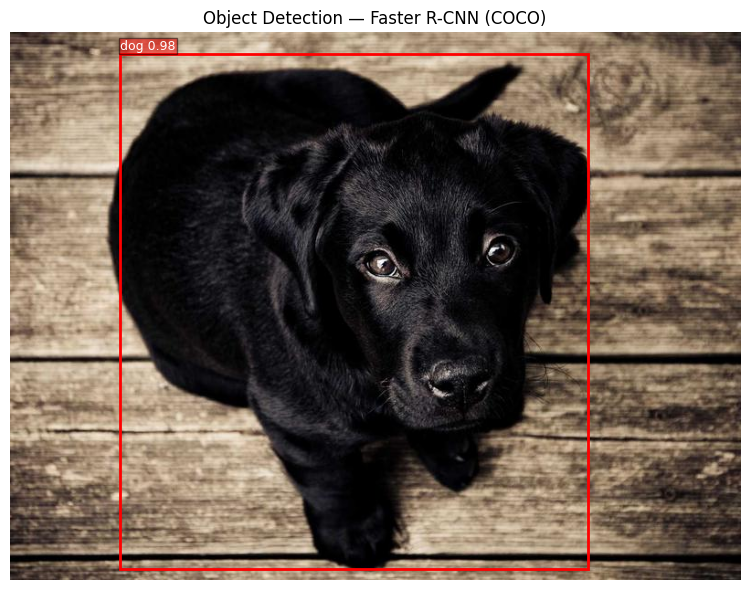

In [36]:
import matplotlib.patches as patches

# COCO class names (91 classes)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

threshold = 0.5
boxes  = prediction[0]['boxes'].cpu()
scores = prediction[0]['scores'].cpu()
labels = prediction[0]['labels'].cpu()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(img)

for box, score, label in zip(boxes, scores, labels):
    if score >= threshold:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        ax.text(x1, y1 - 5, f'{class_name} {score:.2f}',
                color='white', fontsize=9,
                bbox=dict(facecolor='red', alpha=0.5, pad=1))

ax.set_title('Object Detection — Faster R-CNN (COCO)')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Summary

| Section | Topic | Key Takeaway |
|---------|--------|--------------|
| 1.1 | Image Processing | OpenCV reads BGR; use `cvtColor` before Matplotlib display |
| 1.2.1 | MLP on CIFAR-10 | Flatten 3×32×32 → 3072 features; limited accuracy (~45-50%) |
| 1.2.2 | CNN on CIFAR-10 | Spatial feature extraction; better accuracy (~60-65%) |
| 1.2.3 | Transfer Learning | Pre-trained features dramatically boost accuracy on small datasets |
| 1.3 | Object Detection | Detect & localize multiple objects with bounding boxes |